# **Raport: Lista 2**

## 1. Wybór i opis zbioru danych

1. **`Zbiór: Telco Customer Churn`** pobrany z platformy Kaggle. Klasyczny, bardzo czytelny zbiór podany w "proponowanych zbiorach danych" w liście, spełnia wymogi instrukcji oraz idealnie wpasowuje się w zalecany rozmiar, co pozwala na wiarygodny podział na zbiór treningowy i testowy bez ryzyka przeuczenia "na pamięć". Biznesowy charakter danych (przewidywanie odejścia klienta) sprawia, że tworzenie logicznych reguł decyzyjnych jest intuicyjne.

2. **Opis Zbioru:**
    1. **Zmienna docelowa:**
        *   **Churn** - czy klient zrezygnował z usług w ostatnim miesiącu (`bool`).

    2. **Dane demograficzne klienta:**
        *   **CustomerID** - unikalne ID klienta (`string`).
        *   **Gender** - płeć (`Male / Female- string`).
        *   **SeniorCitizen** - czy klient jest seniorem (`bool`).
        *   **Partner** - czy klient ma partnera (`bool`).
        *   **Dependents** - czy klient ma kogoś na utrzymaniu (`bool`).

    3. **Informacje o koncie i płatnościach:**
        *   **Tenure** - liczba miesięcy klienta w firmie (`int`).
        *   **Contract** - rodzaj zawartej umowy (`string`).
        *   **PaperlessBilling** - czy klient korzysta z faktur elektronicznych (`bool`).
        *   **PaymentMethod** - sposób płatności (`string`).
        *   **MonthlyCharges** - miesięczna kwota abonamentu (`float`).
        *   **TotalCharges** - całkowita kwota zapłacona przez klienta od początku umowy (`float`).

    4. **Posiadane usługi:**
        *   **PhoneService** - czy posiada telefon stacjonarny (`bool`).
        *   **MultipleLines** - czy posiada wiele linii telefonicznych (`string`).
        *   **InternetService** - dostawca internetu (`string`).
        *   **OnlineSecurity** - czy wykupił bezpieczeństwo online (`string`).
        *   **OnlineBackup** - czy posiada kopię zapasową online (`string`).
        *   **DeviceProtection** - czy posiada ubezpieczenie sprzętu (`string`).
        *   **TechSupport** - czy wykupił wsparcie techniczne (`string`).
        *   **StreamingTV / StreamingMovies** - czy korzysta z serwisów streamingowych dostarczanych przez firmę (`string`).

3. **Kluczowe dane w zbiorze:**
    1. **Cechy liczbowe (numeryczne / ciągłe):**
        *   **`MonthlyCharges`**
        *   **`TotalCharges`**
        *   **`tenure`**

    2. **Cechy kategorialne (tekstowe / dyskretne):**
        * **`Contract`**
        * **`OnlineSecurity`**
        * **`InternetService`**
        * **`TechSupport`**
        * **`OnlineBackup`**
        * **`StreamingMovies`**
        * **`StreamingTV`** 
        * **`DeviceProtection`**

In [803]:
# wczytanie potrzebnych bibliotek
import pandas
import matplotlib.pyplot as plt

import sys
sys.path.append('..') # dodanie glownego foldera do projektu

# wczytanie danych i ustawienie precyzji
pandas.set_option("display.precision", 2)
df = pandas.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Preprocessing

In [804]:
from sklearn.model_selection import train_test_split
import src.utils.utils as utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

columns_to_encode = [
	'gender',
	'MultipleLines', 
	'InternetService', 
	'OnlineSecurity', 
	'OnlineBackup',
	'DeviceProtection', 
	'TechSupport', 
	'StreamingTV', 
	'StreamingMovies',
	'Contract', 
	'PaymentMethod'
]
TEST_SIZE = 0.2

# czyszczenie danych i konwersja kolumn
df = df.drop('customerID', axis=1)

utils.map_dtypes_str_to_float(df, 'TotalCharges')
utils.map_dtypes_str_to_float(df, 'MonthlyCharges')
utils.map_dtypes_str_to_bool(df, 'Partner')
utils.map_dtypes_str_to_bool(df, 'Dependents')
utils.map_dtypes_str_to_bool(df, 'PhoneService')
utils.map_dtypes_str_to_bool(df, 'PaperlessBilling')
utils.map_dtypes_str_to_bool(df, 'Churn')

# oddzielenie zmeinnych objasniajacych od docelowej
x = df.drop('Churn', axis=1)
y = df['Churn']

# podzial danych
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=42) # random_state = 42 daje powtarzalność wylosowanych danych

# mapowanie wieloklasowych cech danych kategorialnych
x_train, x_test = utils.apply_one_hot_encoding(x_train, x_test, columns_to_encode)

print(f"Rozmiar całego zbioru: {df.shape[0]}")
print(f"Rozmiar zbioru treningowego: {x_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {x_test.shape[0]}")

Rozmiar całego zbioru: 7043
Rozmiar zbioru treningowego: 5634
Rozmiar zbioru testowego: 1409


## 3. Drzewa Decyzyjne (3.0)

### Trening gotowego modelu

In [805]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Predykcja na zbiorze testowym i metryki

In [806]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

y_pred = tree_model.predict(x_test)

print(classification_report(y_test, y_pred)) # wypisanie precision, recall, f1 score i accuracy dla poszczególnych klas

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f} [(True Positives / Total Predicted Positives)]")
print(f"Recall: {recall:.2f}[(True Positives / Total Actual Positives)]")
print(f"F1 Score: {f1:.2f} [2 * (Precision * Recall) / (Precision + Recall)]")

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409

Accuracy: 0.81
Precision: 0.70 [(True Positives / Total Predicted Positives)]
Recall: 0.46[(True Positives / Total Actual Positives)]
F1 Score: 0.56 [2 * (Precision * Recall) / (Precision + Recall)]


### Wnioski
Zbiór danych jest **niezbalansowany**– klientów lojalnych (klasa 0) jest znacznie więcej niż odchodzących (klasa 1). Z tego powodu sama metryka **Accuracy (Dokładność)**, wynosząca +/- 81%, jest myląca. Model mógłby sztucznie osiągać wysokie Accuracy, zawsze zgadując klasę 0.

Dlatego, do oceny jakości modelu wykorzystano inne metryki:
* **Precision:** model wskazał klienta jako odchodzącego- w ilu procentach przypadków miał rację. Chroni przed false positives.
* **Recall:** ilu faktycznie odchodzących klientów algorytm zdołał wyłapać (true positives). Jak widać w raporcie i na macierzy pomyłek, recall dla klasy 1 jest stosunkowo niski. Model przegapia znaczną część uciekających klientów (False Negatives).
* **F1-Score:** średnia harmoniczna Recall i Precision. Na niezbalansowanym miarodajny wskaźnik jakości modelu.

## Interpretacja Drzewa i Ważność Cech (3.5)

### Wizualizacja reguł

In [807]:
from sklearn.tree import export_text
import pandas as pd

# wykrycie reguł drzewa
print("---- Reguły wygenerowane przez drzewo ----")
tree_conditions = export_text(tree_model, feature_names=list(x_train.columns))
print(tree_conditions)

print("\n---- Ważność cech ----")
importances = pd.DataFrame({
    'Cecha': x_train.columns,
    'Ważność': tree_model.feature_importances_
}).sort_values(by='Ważność', ascending=False)

display(importances.head(5)) # 5 najważniejszych cech
display(importances.tail(3)) # 3 najmniej ważne cechy

---- Reguły wygenerowane przez drzewo ----
|--- tenure <= 16.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 3.50
|   |   |   |--- StreamingMovies_No internet service <= 0.50
|   |   |   |   |--- MonthlyCharges <= 60.20
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MonthlyCharges >  60.20
|   |   |   |   |   |--- class: 0
|   |   |   |--- StreamingMovies_No internet service >  0.50
|   |   |   |   |--- TotalCharges <= 24.52
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- TotalCharges >  24.52
|   |   |   |   |   |--- class: 0
|   |   |--- tenure >  3.50
|   |   |   |--- DeviceProtection_No internet service <= 0.50
|   |   |   |   |--- TotalCharges <= 310.90
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- TotalCharges >  310.90
|   |   |   |   |   |--- class: 0
|   |   |   |--- DeviceProtection_No internet service >  0.50
|   |   |   |   |--- TotalCharges <= 397.23
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- TotalCharges >  397.23

,Cecha,Ważność
3,tenure,0.45
11,InternetService_Fiber optic,0.34
7,TotalCharges,0.05
28,PaymentMethod_Electronic check,0.03
6,MonthlyCharges,0.02


,Cecha,Ważność
22,StreamingTV_Yes,0.0
27,PaymentMethod_Credit card (automatic),0.0
29,PaymentMethod_Mailed check,0.0


### Najważniejsze cechy
Algorytm pokazał dominację dwóch cech:
1. **`tenure`** (0.45) - staż klienta.
2. **`InternetService_Fiber optic`** (0.34) - posiadanie internetu światłowodowego.
Kolejne `TotalCharges` (0.05), `PaymentMethod_Electronic check` (0.03) i `MonthlyCharges` (0.02), miały już bardzo małe znaczenie.

Korzeniem drzewa (najważniejszym pierwszym podziałem) jest warunek `tenure <= 16.50`. Z punktu widzenia biznesu ma to głęboki sens – nowi klienci (będący z firmą krócej niż półtora roku) są najbardziej skłonni do odejścia, ponieważ nie zdążyli jeszcze przywiązać się do usługodawcy. 
Zaraz pod nim, na obu gałęziach, znajduje się podział względem `InternetService_Fiber optic`. To również logiczne: światłowód to usługa droga. Jeśli klient jest "świeży" (niski staż) i od razu płaci wysokie rachunki za światłowód, jego ryzyko rezygnacji drastycznie rośnie. 

### Porównanie z systemem reguł z listy 1
Logika algorytmu pokrywa się z modelem z listy 1, choć różni się kolejnością podejmowania decyzji:

* **Zbieżności:** Model z listy 1 opierał się na wyłapywaniu klientów o krótkim stażu (`tenure <= 10` lub `<= 20`), posiadających światłowód (`InternetService_Fiber optic`) i płacących wysokie rachunki (`MonthlyCharges > 70`). Algorytm drzewa decyzyjnego zrobił to samo- na szczycie szukał klientów z stażem `<= 16.50` oraz tych ze światłowodem, a w dalszych krokach analizował wysokość opłat (`Total/MonthlyCharges`).
* **Różnice:** Pierwszym warunkiem modelu z listy 1 był rodzaj umowy (`Contract_One/Two year`), ponieważ dawało to od razu pewność lojalności. Tutaj algorytm ustalił że to `tenure` daje największy zysk informacyjny na samym początku, a rodzaj umowy (`Contract_Two year <= 0.50`) sprawdził dopiero na 3 poziomie zagnieżdżenia. Dodatkowo wychwycił wpływ metody płatności (`Electronic check`).

**Podsumowanie:** Algorytm potwierdził trafność analizy EDA z Listy 1. Udowodnił, że staż klienta, technologia internetowa i koszty to najważniejsze cechy do przewidywania rezygnacji.

### Implementacja funkcji obliczających Entropię i Zysk Informacyjny do weyfikacji wyników

In [808]:
#tenure 16.5 (wazna cecha) ---
split = x_train['tenure'] <= 16.50
y_left = y_train[split]
y_right = y_train[~split] # ~ daje > 16.5

ig = utils.information_gain(y_train, y_left, y_right)
print(f"cecha tenure <= 16.50 zysk informacyjny: {ig:.4f}")

#StreamingTV_Yes 0.0 (mało ważna cecha)
split = x_train['StreamingTV_Yes'] <= 0.5
y_left = y_train[split]
y_right = y_train[~split]

ig = utils.information_gain(y_train, y_left, y_right)
print(f"cecha StreamingTV_Yes zysk informacyjny: {ig:.4f}")

cecha tenure <= 16.50 zysk informacyjny: 0.0716
cecha StreamingTV_Yes zysk informacyjny: 0.0026


### Wnioski

Zgodnie z wyliczeniami, podział zbioru na podstawie stażu klienta (`tenure`) wygenerował dużo wyższy zysk informacyjny (**0.0716 bita**) względem podziału usługi telewizyjnej (**0.0026 bita**). Udowadnia to mechanizm drzew decyzyjnych– w każdym węźle algorytm "zachłannie" wybiera cechę, która maksymalizuje spadek entropii. Ponieważ usługa TV dawała znikomy zysk, drzewo nie użyło jej do podziału, przez co jej finalna ważność w wyuczonym modelu wyniosła 0.0. Różnica w wartościach bezwzględnych między moim Zyskiem (0.0716), a ważnością (0.45) wynika z faktu, że biblioteka domyślnie wykorzystuje inne kryterium (Giniego a nie Entropię), a wynikowy wskaźnik **Feature Importance** jest sumą spadku zanieczyszczeń ze wszystkich węzłów w całym drzewie, w których dana cecha została wykorzystana.

## Regresja liniowa (4.0)

### Metoda Najmniejszych Kwadratów

In [809]:
from src.models.ModelLinearRegressionLeastSquares import ModelLinearRegressionLeastSquares
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

model_least_squares = ModelLinearRegressionLeastSquares()
model_least_squares.fit(x_train, y_train)

### Gradient Descent

In [810]:
from src.models.ModelLinearRegressionGradientDescent import ModelLinearRegressionGradientDescent

model_gradient_descent = ModelLinearRegressionGradientDescent()
model_gradient_descent.fit(x_train, y_train, learning_rate=1e-7, epochs=100)

### LinearRegression ze scikit-learn

In [811]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Porównanie

<b>Weryfikacja wag: </b>

In [812]:
print(f"1. Scikit-Learn: \nIntercept = {sklearn_model.intercept_:.4f}, \nWagi = {sklearn_model.coef_.round(4)}")
print(f"2. Metoda Najmniejszych Kwadratów: \nIntercept = {model_least_squares.intercept:.4f}, \nWagi = {model_least_squares.coef.round(4)}")
print(f"3. Gradient Descent: \nIntercept = {model_gradient_descent.intercept:.4f}, \nWagi = {model_gradient_descent.coef.round(4)}")

print("\n---- BŁĘDY NA ZBIORZE TESTOWYM ----")
models = {
    "Scikit-Learn": sklearn_model,
    "Metoda Najmniejszych Kwadratów": model_least_squares,
    "Gradient Descent": model_gradient_descent
}

for name, model in models.items():
    preds = model.predict(x_test)
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    print(f"{name:<25} | MSE: {mse:.2f} | MAE: {mae:.2f}")

1. Scikit-Learn: 
Intercept = 0.5217, 
Wagi = [ 0.0378  0.0071 -0.0231 -0.0019  0.0265  0.0454 -0.0044 -0.     -0.0085
 -0.0265  0.0714  0.2812 -0.0364 -0.0364 -0.035  -0.0364 -0.0008 -0.0364
  0.0218 -0.0364 -0.027  -0.0364  0.0882 -0.0364  0.107  -0.1073 -0.0808
 -0.0044  0.0706 -0.0038]
2. Metoda Najmniejszych Kwadratów: 
Intercept = 0.3478, 
Wagi = [ 0.0378  0.0071 -0.0231 -0.0019  0.2004  0.0454 -0.0044 -0.     -0.0085
  0.1474  0.0714  0.2812 -0.0364 -0.0364 -0.035  -0.0364 -0.0008 -0.0364
  0.0218 -0.0364 -0.027  -0.0364  0.0882 -0.0364  0.107  -0.1073 -0.0808
 -0.0044  0.0706 -0.0038]
3. Gradient Descent: 
Intercept = -0.0000, 
Wagi = [-0.     -0.     -0.     -0.0005 -0.     -0.     -0.0005 -0.0421 -0.
 -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.
 -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.
 -0.     -0.     -0.    ]

---- BŁĘDY NA ZBIORZE TESTOWYM ----
Scikit-Learn              | MSE: 0.13 | MAE: 0.29
Metoda Najmniejszych Kwadrató

Próba zrównania modelu spadku gradientu (iteracyjnego) z analitycznym na surowych danych okazała się ciężka. Duża różnica w rzędach wielkości cech (kolumny binarne 0/1 vs TotalCharges z wartościami 8000) powoduje eksplozję gradientu. Aby uniknąć przeciążenia model zbiega bardzo wolno i nie dorównuje metodzie analitycznej w sensownej liczbie epok. Udowadnia to konieczność standaryzacji danych.

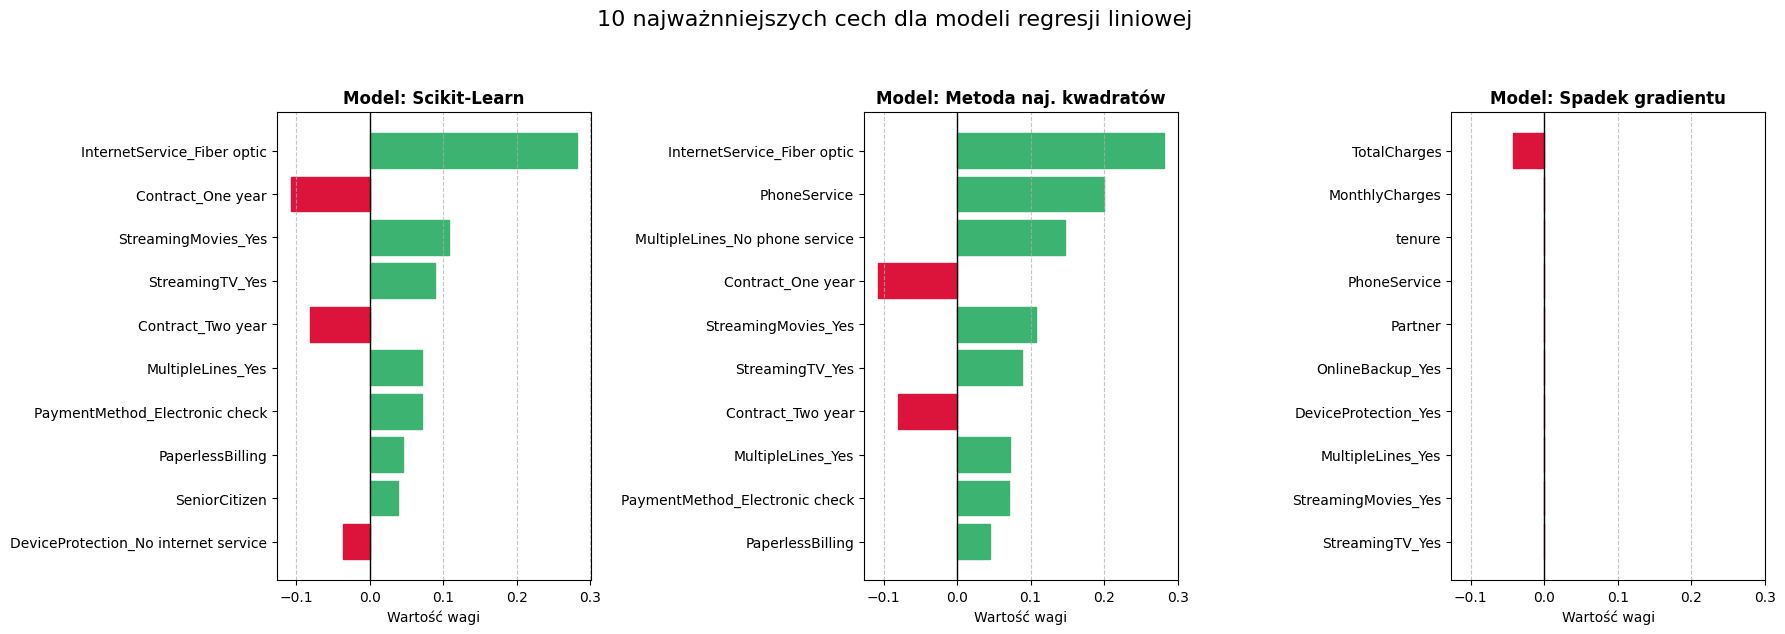

In [813]:
model_weights = {
	"Scikit-Learn": sklearn_model.coef_,
	"Metoda naj. kwadratów": model_least_squares.coef,
	"Spadek gradientu": model_gradient_descent.coef
}

feature_names = x_train.columns

# 3 wykresy w 1 rzedzie
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

for ax, (model_name, weights) in zip(axes, model_weights.items()):
    df_weights = pd.DataFrame({
        'Feature': feature_names,
        'Weight': weights,
        'Abs_Weight': np.abs(weights)
    })
    
    #wziecie 10 najwazniejszych cech (najwyższa wartość bezwzględna)
    df_top10 = df_weights.sort_values(by='Abs_Weight', ascending=False).head(10)
    
    # poziomy wykres słupkowy
    bars = ax.barh(df_top10['Feature'][::-1], df_top10['Weight'][::-1])
    
    # kolorowanie slupkow
    for bar in bars:
        if bar.get_width() > 0:
            bar.set_color('mediumseagreen')
        else:
            bar.set_color('crimson')
            
    # upiekszenie wykresu
    ax.set_title(f"Model: {model_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Wartość wagi")
    ax.axvline(0, color='black', linewidth=1) # linia w 0
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle("10 najważnniejszych cech dla modeli regresji liniowej", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

<b>Wnioski z uczenie na nieprzeskalowanych danych</b>
1. **Porażka iteracyjnego Spadku Gradientu:** Na wykresie widać, że wagi dla cech kategorialnych (0/1) pozostały na zerze, a jedyną cechą, która coś zmienia w modelu jest `TotalCharges`. Wynika to ze wzoru na gradient– kolumny o dużych wartościach liczbowych zdominowały proces aktualizacji wag. Ze względu na ryzyko eksplozji gradientu współczynnik uczenia musiał być na tyle mały, że model nie zdołał się niczego nauczyć o cechach binarnych.
2. **Niestabilność Metody Analitycznej:** Wykres drugi pokazuje, że operacje na macierzach również ucierpiały. W nieprzeskalowanej, źle uwarunkowanej macierzy uwydatnił się problem współliniowości– algorytm przypisał większe (fałszywe) wagi do tożsamych cech (`PhoneService` i `MultipleLines_No phone service`), rozjeżdżając się z wynikami biblioteki Scikit-Learn.
3. **Myląca interpretacja (Scikit-Learn):** W modelu scikit-learn waga zmiennej `TotalCharges` jest niewidoczna na wykresie. Nie oznacza to jednak, że nie ma ona wpływu na wynik – waga jest mała tylko dlatego, aby zrównoważyć znacznie większe wartości samej cechy. 

## Interpretacja Regresji i Skalowanie (4.5)

### Skalowanie

In [814]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np

# skalowanie danych tylko na zbiorze treningowym
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) # na testowych danych tylko transform

# trenowanie modeli na zeskalowanych danych
# scikit-Learn
model_sk = LinearRegression()
model_sk.fit(x_train_scaled, y_train)

# najmniejsze kwadraty
model_ls = ModelLinearRegressionLeastSquares()
model_ls.fit(x_train_scaled, y_train)

# spadek gradientu
model_gd = ModelLinearRegressionGradientDescent()
model_gd.fit(x_train_scaled, y_train, learning_rate=0.1, epochs=50000)

print("\n---- WAGI PO SKALOWANIU ----")
print(f"Scikit-Learn: {model_sk.coef_.round(4)}")
print(f"Najmniejsze kwadraty: {model_ls.coef.round(4)}")
print(f"Gradient descent: {model_gd.coef.round(4)}")


---- WAGI PO SKALOWANIU ----
Scikit-Learn: [ 0.0139  0.0036 -0.0106 -0.047   0.0079  0.0223 -0.1336 -0.0952 -0.0043
 -0.0079  0.0353  0.1396 -0.015  -0.015  -0.0158 -0.015  -0.0004 -0.015
  0.0104 -0.015  -0.0122 -0.015   0.043  -0.015   0.0522 -0.0441 -0.0344
 -0.0018  0.0333 -0.0016]
Najmniejsze kwadraty: [ 0.0139  0.0036 -0.0106 -0.047   0.0079  0.0223 -0.1336 -0.0952 -0.0043
 -0.0079  0.0353  0.1396 -0.015  -0.015  -0.0158 -0.015  -0.0004 -0.015
  0.0104 -0.015  -0.0122 -0.015   0.043  -0.015   0.0522 -0.0441 -0.0344
 -0.0018  0.0333 -0.0016]
Gradient descent: [ 0.0139  0.0036 -0.0106 -0.047   0.0079  0.0223 -0.1336 -0.0952 -0.0043
 -0.0079  0.0353  0.1396 -0.015  -0.015  -0.0158 -0.015  -0.0004 -0.015
  0.0104 -0.015  -0.0122 -0.015   0.043  -0.015   0.0522 -0.0441 -0.0344
 -0.0018  0.0333 -0.0016]


### Ponowne wytrenowanie modeli na przeskalowanych cechach przyniosło to dwa rezultaty:
1. **Sukces metody iteracyjnej:** Spadek Gradientu, który wcześniej wybuchał lub zbiegał wolno z powodu różnych rzędów wielkości danych, po skalowaniu zadziałał i dorównał metodzie analitycznej i implementacji ze Scikit-Learn (taka sama wartość wag).
2. **Możliwość poprawnej interpretacji:** Dopiero dzięki przeskalowaniu można odpowiedzieć, która cecha jest najważniejsza.

<b>Co oznacza waga przy konkretnej cesze?</b>
Równanie regresji liniowej to zbiór wag (mnożników) dla każdej cechy. 
* Jeśli waga wynosi <b>3.5</b>, oznacza to, że wzrost danej cechy o jedną jednostkę (w przypadku przeskalowanych danych o jedno odchylenie standardowe) powoduje wzrost przewidywanego wyniku o 3.5, przy założeniu, że wszystkie pozostałe cechy się nie zmieniają.
* Jeśli waga wynosi <b>-1.2</b> oznacza to odwrotność– wzrost cechy powoduje spadek wyniku o 1.2.

<b>Dlaczego brak skalowania może prowadzić do fałszywych wniosków</b>
W nieprzeskalowanym modelu są dwie cechy: binarną zmienną określającą płeć oraz całkowite opłaty klienta (TotalCharges np. od 20 do 8000). 
Matematyka modelu regresji siłą rzeczy przypisze dużą wagę zmiennej płci (np. 1500), a bardzo małą wagę opłatom (np. 0.005), aby wyrównać różnicę wartości liczbowych do przewidywanego wyniku. Przez to można dojść do fałszywego wniosku odnośnie tego, że płeć była by ważniejsza od opłat, co jest nie prawdą gdyż wartość wagi bierze się z różnicy w rzędach wielkości tych cech. Właśnie `StandardScaler` spłaszcza kolumnę do ustandaryzowanego rozkładu o średniej 0 i odchyleniu 1 wtedy wagi stają się porównywalne ze sobą. 


---- NAJWAŻNIEJSZEJSZA CECHA MODELI ----
Scikit-Learn              | Najważniejsza cecha: InternetService_Fiber optic    | Waga: 0.1396
Metoda naj. kwadratów     | Najważniejsza cecha: InternetService_Fiber optic    | Waga: 0.1396
Spadek gradientu          | Najważniejsza cecha: InternetService_Fiber optic    | Waga: 0.1396


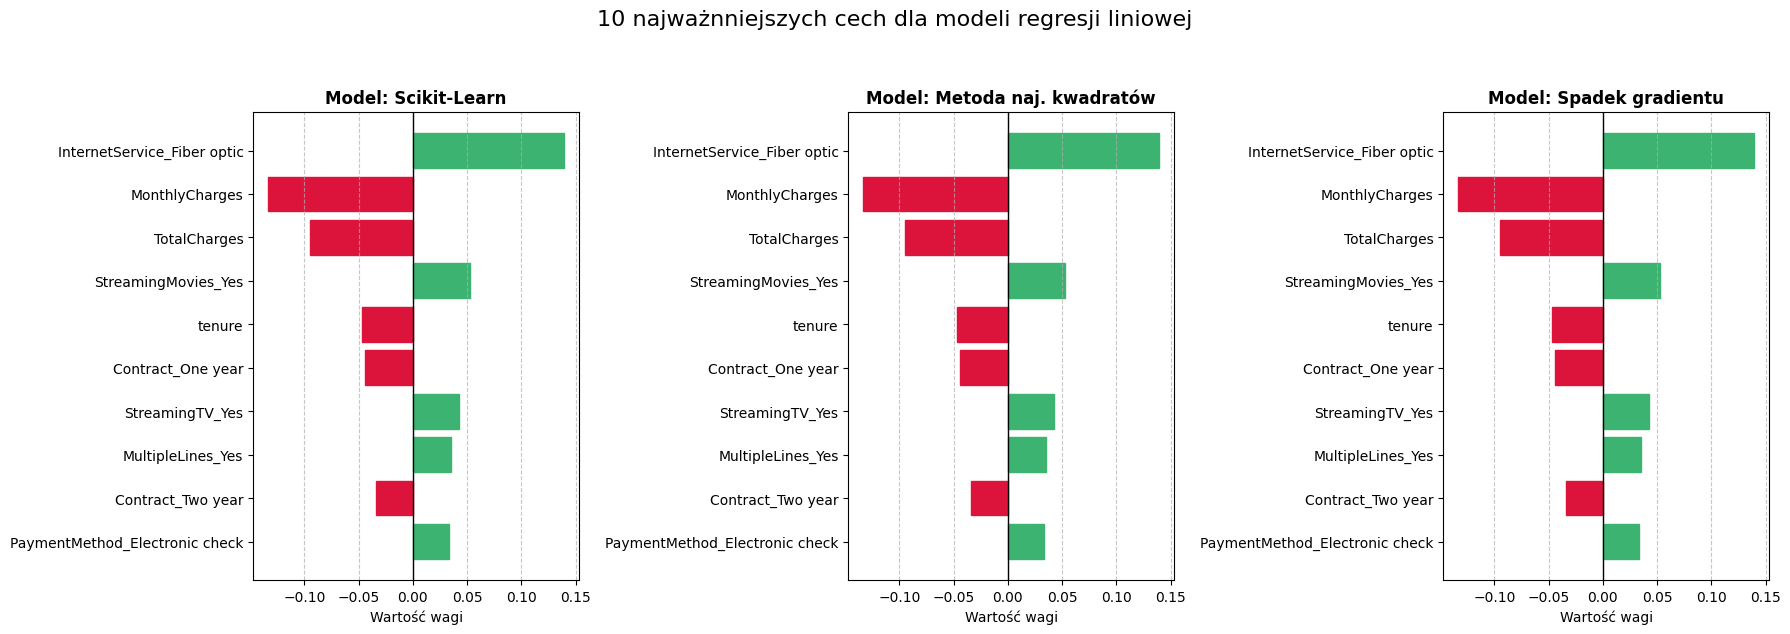

In [815]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n---- NAJWAŻNIEJSZEJSZA CECHA MODELI ----")
model_weights = {
	"Scikit-Learn": model_sk.coef_,
	"Metoda naj. kwadratów": model_ls.coef,
	"Spadek gradientu": model_gd.coef
}

for name, weight in model_weights.items():
    idx_max = np.argmax(np.abs(weight))
    most_important_att = x_train.columns[idx_max]
    weight_value = weight[idx_max]
    
    print(f"{name:<25} | Najważniejsza cecha: {most_important_att:<30} | Waga: {weight_value:.4f}")


# wizualizacja wag
feature_names = x_train.columns

# 3 wykresy w 1 rzedzie
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

for ax, (model_name, weights) in zip(axes, model_weights.items()):
    df_weights = pd.DataFrame({
        'Feature': feature_names,
        'Weight': weights,
        'Abs_Weight': np.abs(weights)
    })
    
    #wziecie 10 najwazniejszych cech (najwyższa wartość bezwzględna)
    df_top10 = df_weights.sort_values(by='Abs_Weight', ascending=False).head(10)
    
    # poziomy wykres słupkowy
    bars = ax.barh(df_top10['Feature'][::-1], df_top10['Weight'][::-1])
    
    # kolorowanie slupkow
    for bar in bars:
        if bar.get_width() > 0:
            bar.set_color('mediumseagreen')
        else:
            bar.set_color('crimson')
            
    # upiekszenie wykresu
    ax.set_title(f"Model: {model_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Wartość wagi")
    ax.axvline(0, color='black', linewidth=1) # linia w 0
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle("10 najważnniejszych cech dla modeli regresji liniowej", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

<b>Cecha, która ma największy wpływ</b>
Po przeskalowaniu, wystarczy znaleźć wagę o **najwyższej wartości bezwzględnej**. Dla modelów największy wpływ na zmienną docelową ma cecha `InternetService_Fiber optic`.

## Bias-Variance i Problem Czarnego Łabędzia (5.0)

Text(0.5, 1.0, 'Funkcja')

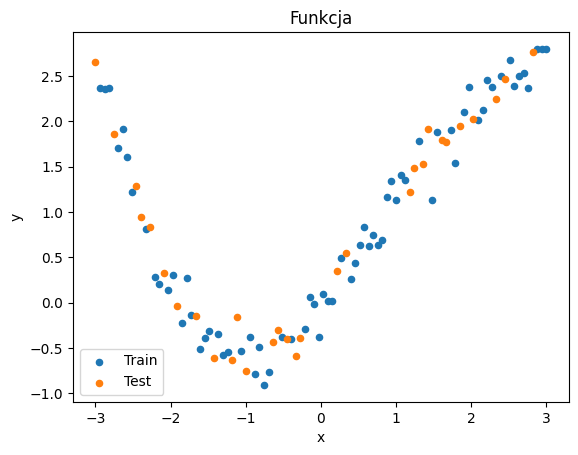

In [816]:
# wygenerowanie nieliniowych danych
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
# y = 0.5x^2 + x + 2 + szum
y = np.sin(x[:, 0]) + 0.3 * x[:, 0]**2 + np.random.normal(0, 0.2, size=len(x))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

plt.scatter(x_train, y_train, s=20, label="Train")
plt.scatter(x_test, y_test, s=20, label="Test")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Funkcja")

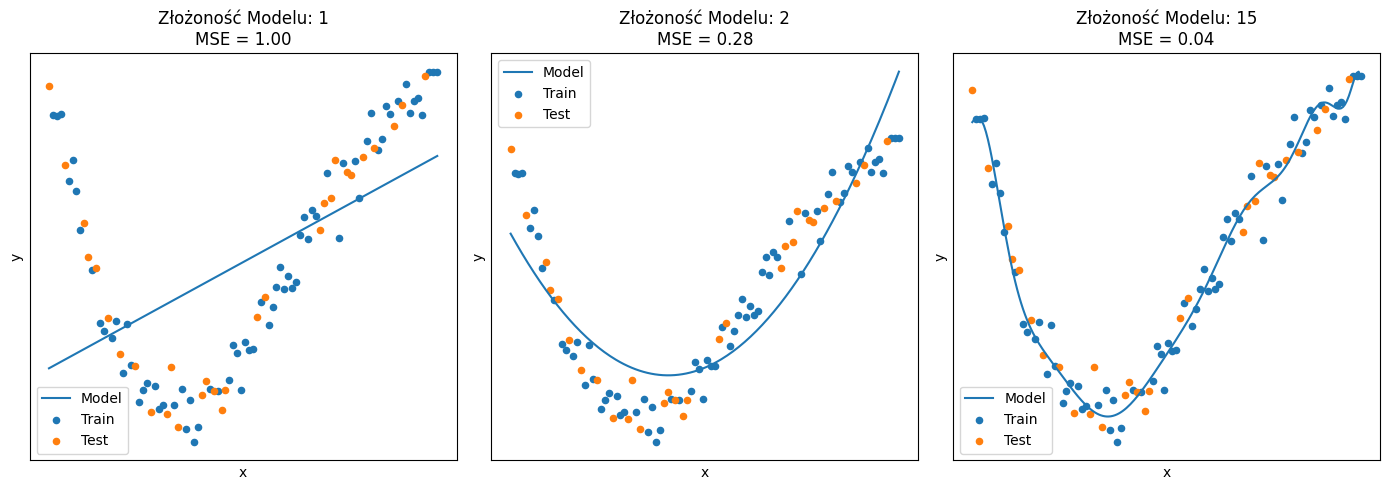

In [817]:

import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2, 15]

def fun(x):
  return np.sin(x) + 0.3 * x**2

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
  
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    
    linear_regression = LinearRegression()
    
    pipeline = Pipeline(
			[
				("polynomial_features", polynomial_features),
				("linear_regression", linear_regression),
			]
    )
    
    # trenowanie
    pipeline.fit(x_train, y_train)

    # crossvalidation
    scores = cross_val_score(pipeline, x_train, y_train, scoring="neg_mean_squared_error", cv=10)

		# dane do rysowania wykresu
    x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    y_plot = pipeline.predict(x_plot)

		# wykres
    plt.plot(x_plot, y_plot, label="Model")

    # punkty danych
    plt.scatter(x_train, y_train, s=20, label="Train")

    plt.scatter(x_test, y_test, s=20, label="Test")

    plt.xlabel("x")
    plt.ylabel("y")

    plt.title(
        f"Złożoność Modelu: {degrees[i]}\n"
        f"MSE = {-scores.mean():.2f}")

    plt.legend()

plt.tight_layout()
plt.show()

### Krzywe Złożoności (Analiza Bias-Variance)

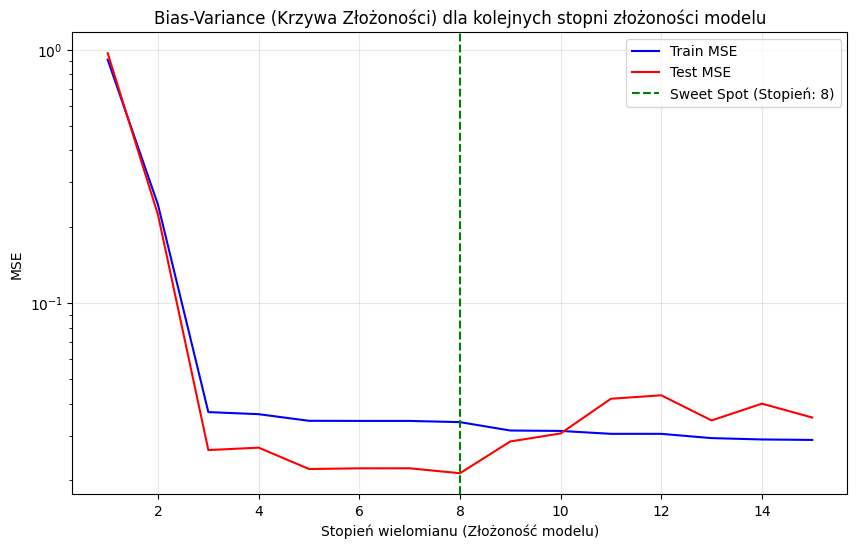

In [818]:
from sklearn.preprocessing import PolynomialFeatures

# petla zwiekszajaca zloznosc modelu (stopnie wielomianu od 1 do 15)
degrees = range(1, 16)

train_errors = []
test_errors =[]

for d in degrees:
    # transformacja na wielomian danego stopnia
    poly = PolynomialFeatures(degree=d)
    x_poly_train = poly.fit_transform(x_train)
    x_poly_test = poly.transform(x_test)
    
    #trenowanie
    model = LinearRegression()
    model.fit(x_poly_train, y_train)
    
    #obliczenie MSE
    train_errors.append(mean_squared_error(y_train, model.predict(x_poly_train)))
    test_errors.append(mean_squared_error(y_test, model.predict(x_poly_test)))

# krzywa zlozonosci z sweet spotem na wykresie
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Train MSE', color='blue')
plt.plot(degrees, test_errors, label='Test MSE', color='red')

# zaznaczenie sweet spot'u
best_degree = degrees[np.argmin(test_errors)]
plt.axvline(best_degree, color='green', linestyle='--', label=f'Sweet Spot (Stopień: {best_degree})')

plt.title("Bias-Variance (Krzywa Złożoności) dla kolejnych stopni złożoności modelu")
plt.xlabel("Stopień wielomianu (Złożoność modelu)")
plt.ylabel("MSE")
plt.yscale('log') # skala logarytmiczna dla zwiekszenia czytelności
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analiza Krzywej Złożoności (Bias-Variance Tradeoff)
Wygenerowany wykres pokazuje:
* **Strefa wysokiego obciążenia (High Bias- underfitting):** Przy stopniu wielomianu równym 1, model był zbyt mało skomplikowany, by pojąć nieliniowe zachowanie danych. Błąd zarówno na zbiorze treningowym, jak i testowym jest wysoki.
* **Sweet spot:** Został osiągnięty przy wielomianie 8 stopnia. Model najlepiej pojął trend i miał najniższy błąd na zbiorze testowym.
* **Strefa wysokiej wariancji (High Variance- overfitting):** Od 10 stopnia wielomianu błąd treningowy zbliża się do zera, ponieważ model o dużej złożoności uczy się na pamięć każdego pojedynczego punktu i zaszumienia. Jednak w zderzeniu z nowymi danymi- ze zbioru testowego, jego predykcje stają się błędne, powoduje to wzrost błędu.

### Problem "Czarnego Łabędzia" (Błąd Ekstrapolacji)

In [ ]:
# czarny labedz- punkt 20% poza zakresem treningowym (max to 3.0 -> 3.6 o 20% poza)
black_swan = np.array([[3.6]])

#trening opytmalnego modelu
poly_opt = PolynomialFeatures(degree=best_degree)
model_opt = LinearRegression().fit(poly_opt.fit_transform(x_train), y_train)
pred_opt = model_opt.predict(poly_opt.transform(black_swan))

#trening przeuczonego modelu
poly_overfit = PolynomialFeatures(degree=15)
model_overfit = LinearRegression().fit(poly_overfit.fit_transform(x_train), y_train)
pred_overfit = model_overfit.predict(poly_overfit.transform(black_swan))

#obliczenie prawdziwej wartosci dla funkji
prawdziwe_y = fun(3.6)

print(f"Prawdziwa oczekiwana wartość y dla X=3.6: {prawdziwe_y:.2f}")
print(f"Predykcja modelu optymalnego (Stopień {best_degree}): {pred_opt[0]:.2f}")
print(f"Predykcja modelu przeuczonego (Stopień 15): {pred_overfit[0]:.2f}")

Prawdziwa oczekiwana wartość y dla X=3.6: 3.45
Predykcja modelu optymalnego (Stopień 8): 1.38
Predykcja modelu przeuczonego (Stopień 15): -252.64


### Wyniki testu:
1. Model optymalny przedłużył trend i przewidział wynik bliski rzeczywistości (1.38).
2. Model przeuczony w przy nowym zakresie eksplodował, zwracając absurdalną liczbę (zależną od wylosowanego szumu). 
`Wniosek:` Przeuczone, skomplikowane modele są bardzo wrażliwe i tracą zdolności poprawnej predykcji w nieznanych zakresach.

### Metody zapobiegania (ograniczania złożoności- regularyzacji)
Aby bronić się przed takimi anomaliami i zmuszać model do generalizacji:
1. **Dla Regresji Liniowej:** techniki **Regularyzacji (L1/Lasso lub L2/Ridge)**. Dodają one do funkcji kosztu karę za posiadanie zbyt wielkich, skrajnych wag dla cech, co uspokaja zygzakowanie się wielomianu.
2. **Dla Drzew Decyzyjnych:** techniki **Przycinania drzewa (Pruning)**. Polegają one na sztucznym nałożeniu parametru `max_depth` lub określeniu minimalnej liczby klientów w liściu (`min_samples_leaf`), aby powstrzymać drzewo przed tworzeniem osobnej reguły decyzyjnej pod każdego pojedynczego klienta.